In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('./Stress Indicators Dataset for Mental Health Classification.csv')
df.head()

,gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,...,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes,stress_type
0,1,20,1,2,2,4,3,1,4,5,...,2,3,1,1,4,1,1,3,2,1
1,0,19,4,5,5,4,4,5,4,5,...,2,4,4,5,5,5,5,3,5,0
2,0,21,4,2,3,3,4,4,1,3,...,2,3,3,3,3,3,4,4,2,1
3,0,20,1,3,2,1,3,1,5,5,...,1,3,3,1,3,5,4,2,3,1
4,0,19,4,3,3,2,3,4,2,3,...,3,2,4,2,2,2,3,4,4,1


# **EXPLORATORY DATA ANALYSIS**

In [4]:
df.shape

(2000, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   gender                   2000 non-null   int64
 1   age                      2000 non-null   int64
 2   stress_experience        2000 non-null   int64
 3   heartbeat_palpitations   2000 non-null   int64
 4   anxiety_tension          2000 non-null   int64
 5   sleep_problems           2000 non-null   int64
 6   restlessness             2000 non-null   int64
 7   headaches                2000 non-null   int64
 8   irritability             2000 non-null   int64
 9   concentration_problems   2000 non-null   int64
 10  sadness_low_mood         2000 non-null   int64
 11  health_issues            2000 non-null   int64
 12  loneliness_isolation     2000 non-null   int64
 13  academic_overload        2000 non-null   int64
 14  peer_competition         2000 non-null   int64
 15  rela

In [6]:
df['stress_type'].value_counts()

,count
stress_type,
1,1828
2,102
0,70


In [7]:
df.describe()

,gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,...,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes,stress_type
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.354000,20.007500,2.975000,2.739500,2.532000,2.767000,2.660500,2.617000,2.701500,2.695000,...,2.453000,2.485500,2.518000,2.418500,2.568000,2.615500,2.740500,3.255000,2.396500,1.016000
std,0.478329,4.776385,1.127391,1.104649,1.201956,1.257578,1.284159,1.256225,1.321844,1.314473,...,1.196874,1.195619,1.246777,1.251855,1.283043,1.290927,1.263708,1.202788,1.111713,0.292894
min,0.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,19.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000
50%,0.000000,19.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000,1.000000
75%,1.000000,20.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.250000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000,1.000000
max,1.000000,100.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2.000000


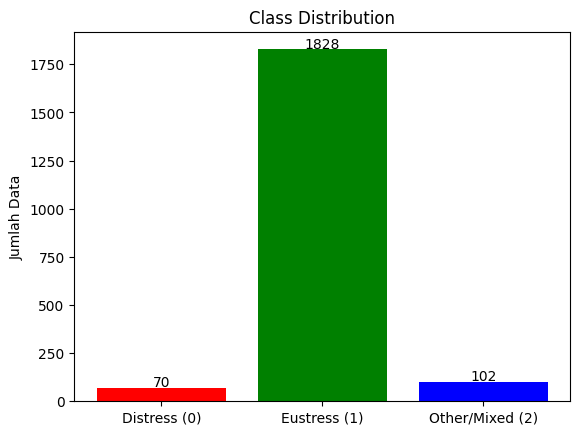

In [8]:
# Class Distribution
class_counts = df['stress_type'].value_counts().sort_index()
class_labels = ['Distress (0)', 'Eustress (1)', 'Other/Mixed (2)']
colors = ['r', 'g', 'b']

plt.bar(class_labels, class_counts.values, color=colors)
plt.title('Class Distribution')
plt.ylabel('Jumlah Data')

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

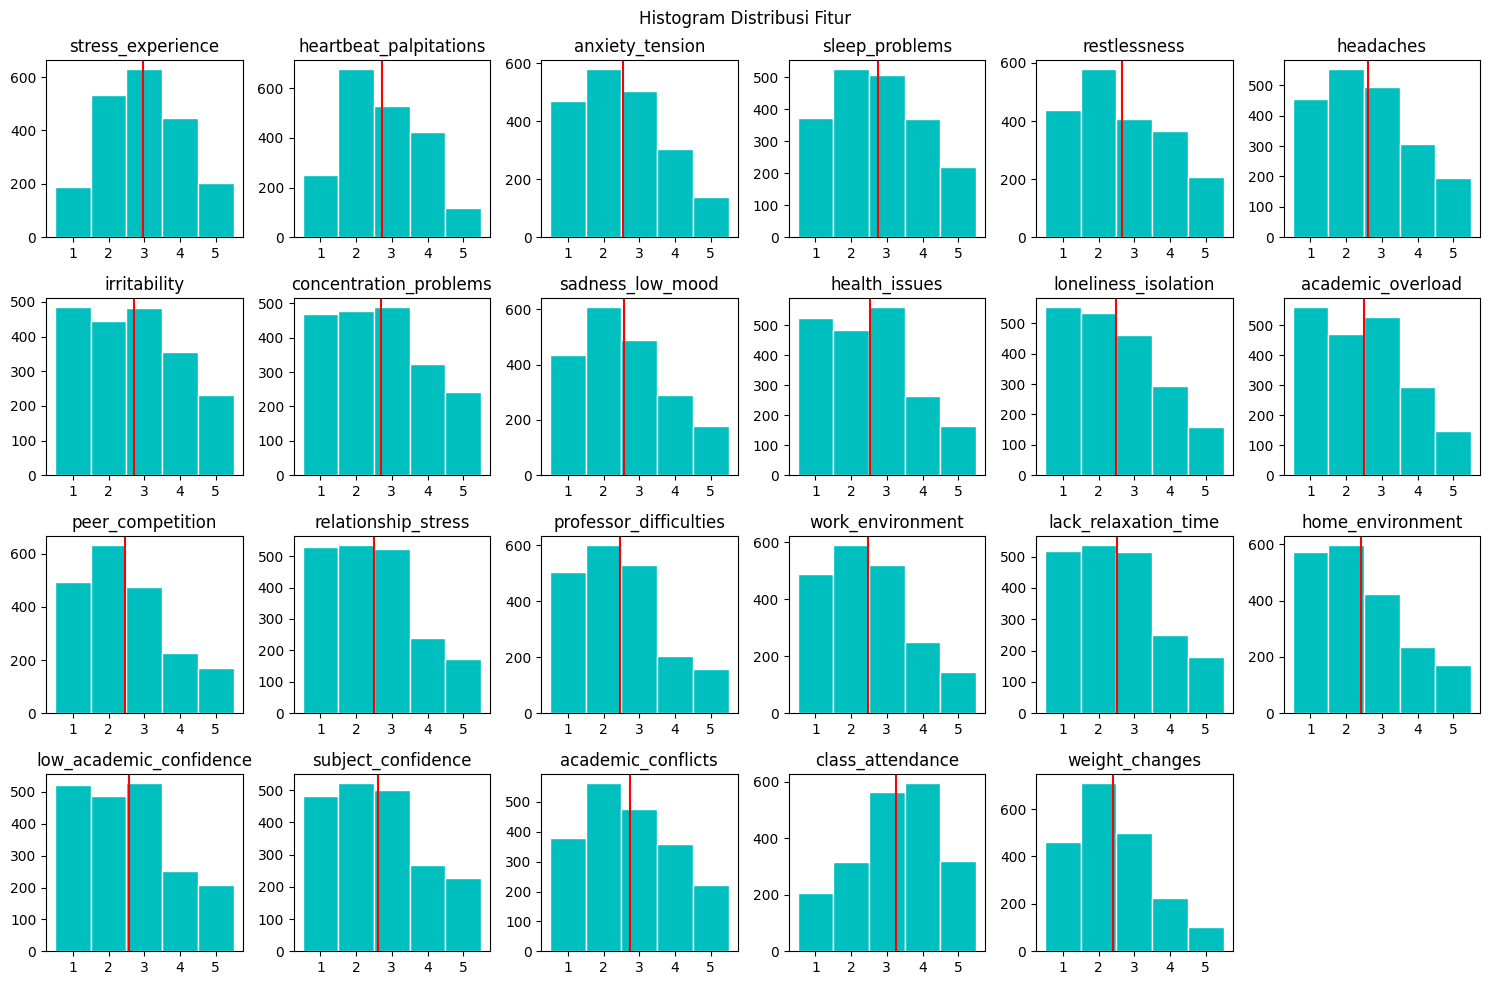

In [9]:
# Histogram Feature (1-5)
scale_cols = df.drop(columns=['gender', 'age', 'stress_type']).columns

plt.figure(figsize=(15, 10))
plt.suptitle('Histogram Distribusi Fitur')

for i, col in enumerate(scale_cols, 1):
    plt.subplot(4, 6, i)
    plt.hist(df[col], bins=5, range=(0.5, 5.5), color='c', edgecolor='white')
    plt.axvline(df[col].mean(), color='r')
    plt.title(col)
    plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

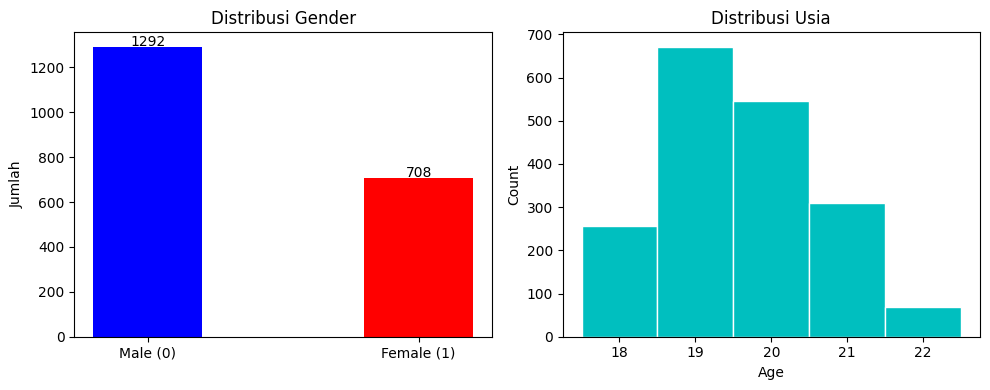

In [10]:
# Histogram Gender & Age
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
gender_counts = df['gender'].value_counts().sort_index()
plt.bar(['Male (0)', 'Female (1)'], gender_counts.values, color=['b', 'r'], width=0.4)
plt.title('Distribusi Gender')
plt.ylabel('Jumlah')

for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.subplot(1, 2, 2)
plt.hist(df['age'], bins=5, range=(17.5, 22.5), color='c', edgecolor='white')
plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks([18, 19, 20, 21, 22])

plt.tight_layout()
plt.show()

# **DATA HANDLING**

In [11]:
# Missing Values
df.isnull().sum()

,0
gender,0
age,0
stress_experience,0
heartbeat_palpitations,0
anxiety_tension,0
sleep_problems,0
restlessness,0
headaches,0
irritability,0
concentration_problems,0


In [12]:
# Check Duplicate
df.duplicated().sum()

np.int64(1191)

In [13]:
# Opsional, namun dalam kasus ini kemungkinan terdapat duplikasi karena terdapat kemungkinan 2 mahasiswa
# memiliki jawaban yang sama. Kemudian dataset ini juga tidak memiliki ID mahasiswa pembeda.
# df = df.drop_duplicates()
# df = df.reset_index(drop=True)
# df.duplicated().sum()

In [14]:
# len(df)

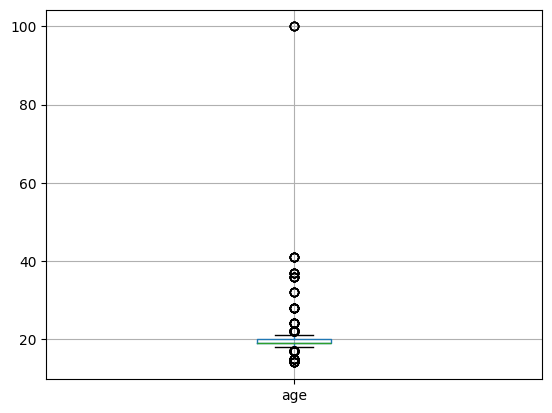

In [15]:
# Boxplot age (Terdapat banyak sekali Outliers, padahal targetnya age 18-22)
df.boxplot(column=['age'])
plt.show()

In [16]:
df = df[(df['age'] >= 18) & (df['age'] <= 22)]
print(f'Total jumlah data setelah dilakukan Filtering: {len(df)}')
print(df['age'].value_counts().sort_index())

Total jumlah data setelah dilakukan Filtering: 1849
age
18    256
19    671
20    545
21    309
22     68
Name: count, dtype: int64


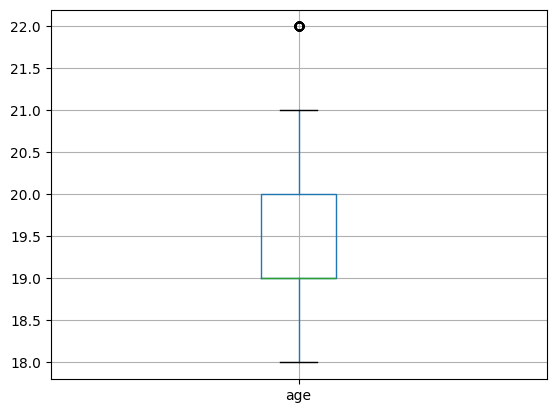

In [17]:
# Outlier age setelah cleaning
df.boxplot(column=['age'])
plt.show()

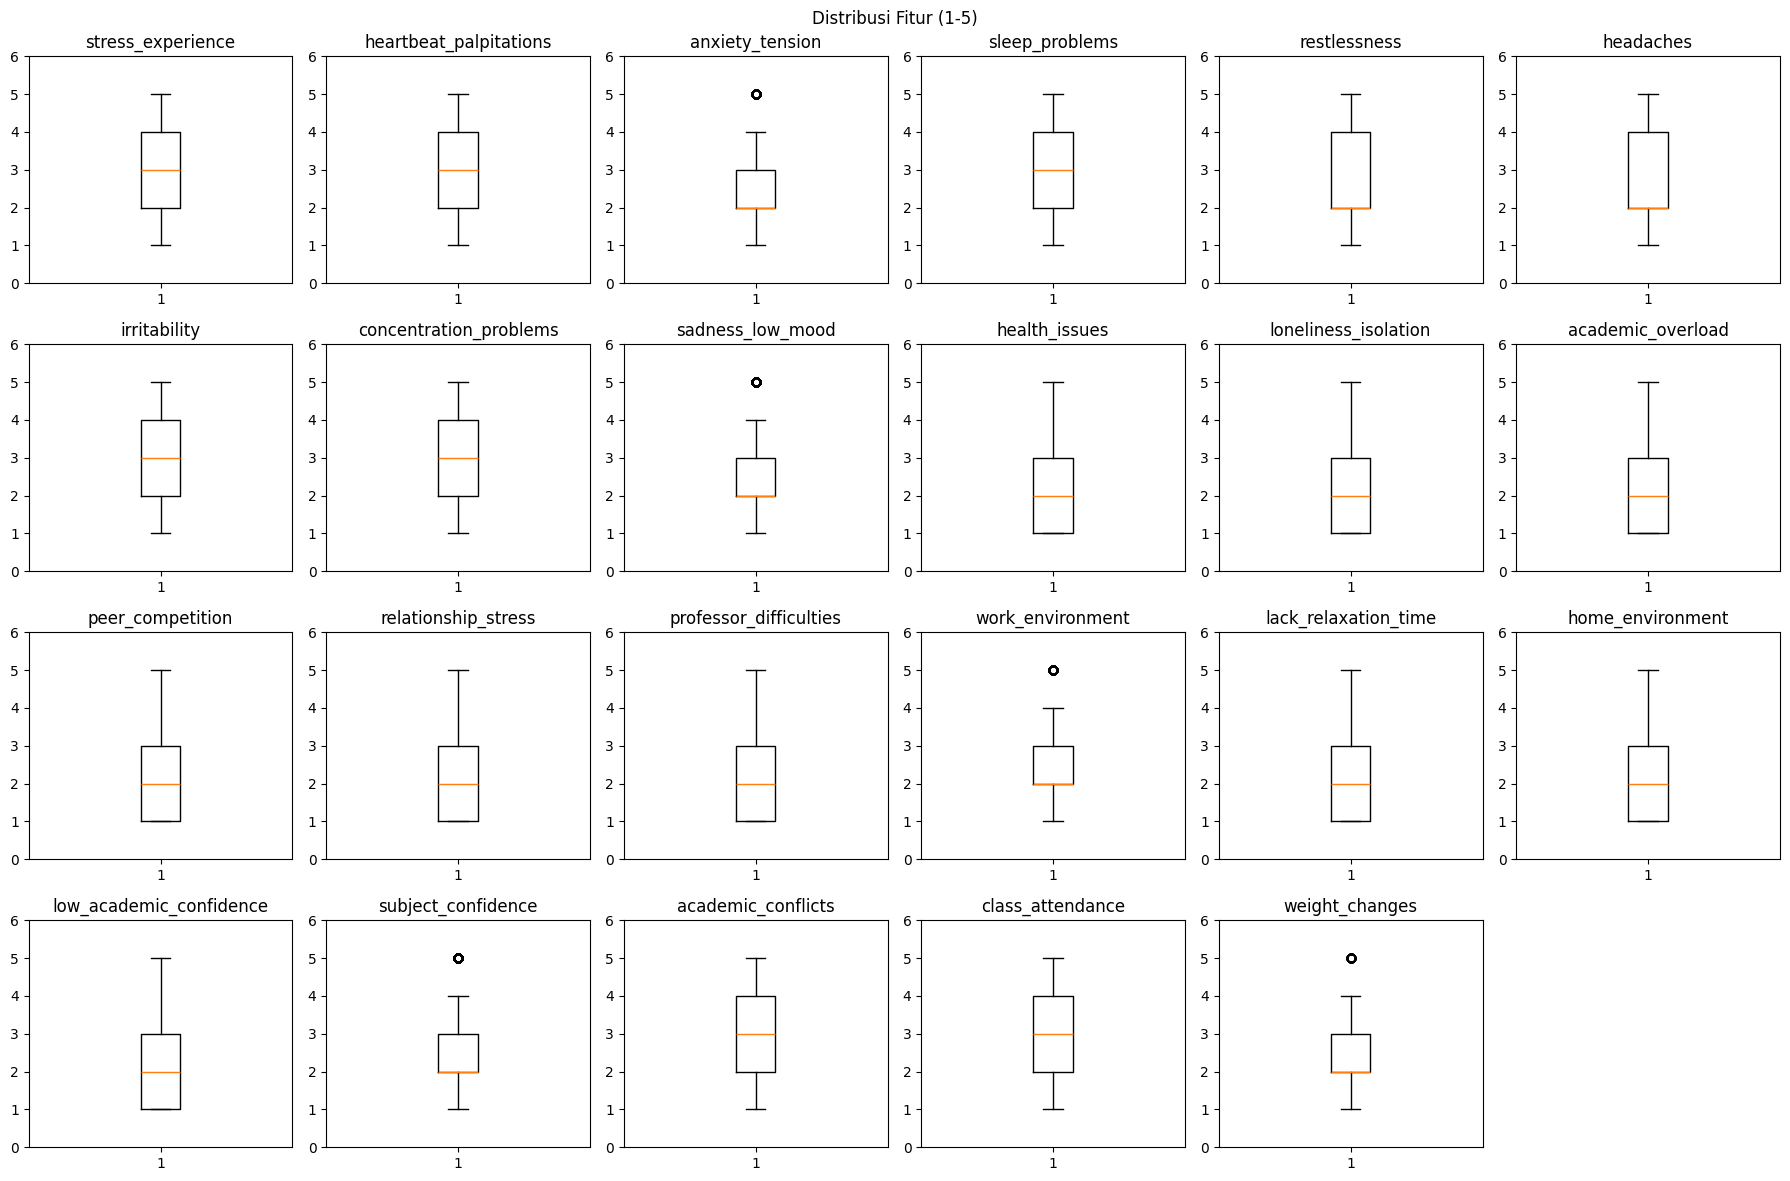

In [18]:
# Outliers skala 1-5
scale_cols = df.drop(columns=['age', 'gender', 'stress_type']).columns

plt.figure(figsize=(18, 12))
plt.suptitle('Distribusi Fitur (1-5)')

for i, col in enumerate(scale_cols, 1):
    plt.subplot(4, 6, i)
    plt.boxplot(df[col])
    plt.title(col)
    plt.ylim(0, 6)

plt.tight_layout()
plt.show()

In [19]:
X = df.drop('stress_type', axis=1)
y = df['stress_type']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
print(f'Size Train (Input): {X_train.shape}')
print(f'Size Test (Input): {X_test.shape}')
print(f'Size Train (Target): {y_train.shape}')
print(f'Size Test (Target): {y_test.shape}')

Size Train (Input): (1479, 25)
Size Test (Input): (370, 25)
Size Train (Target): (1479,)
Size Test (Target): (370,)


In [22]:
X_train.head()

,gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,...,relationship_stress,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes
1614,0,20,2,3,2,1,2,2,4,2,...,3,1,1,1,2,3,2,2,3,2
596,0,20,3,2,2,3,1,4,4,1,...,1,1,4,1,1,2,3,2,2,2
691,1,19,1,1,1,1,1,1,3,2,...,3,3,2,4,2,2,1,1,1,2
779,0,18,2,2,1,4,1,1,1,2,...,2,2,2,2,1,5,1,1,5,2
120,0,19,4,3,2,3,4,2,5,3,...,2,2,3,2,3,1,3,2,2,2


In [23]:
print(X_train.columns)

Index(['gender', 'age', 'stress_experience', 'heartbeat_palpitations',
       'anxiety_tension', 'sleep_problems', 'restlessness', 'headaches',
       'irritability', 'concentration_problems', 'sadness_low_mood',
       'health_issues', 'loneliness_isolation', 'academic_overload',
       'peer_competition', 'relationship_stress', 'professor_difficulties',
       'work_environment', 'lack_relaxation_time', 'home_environment',
       'low_academic_confidence', 'subject_confidence', 'academic_conflicts',
       'class_attendance', 'weight_changes'],
      dtype='object')


# **FEATURE EXTRACTION**

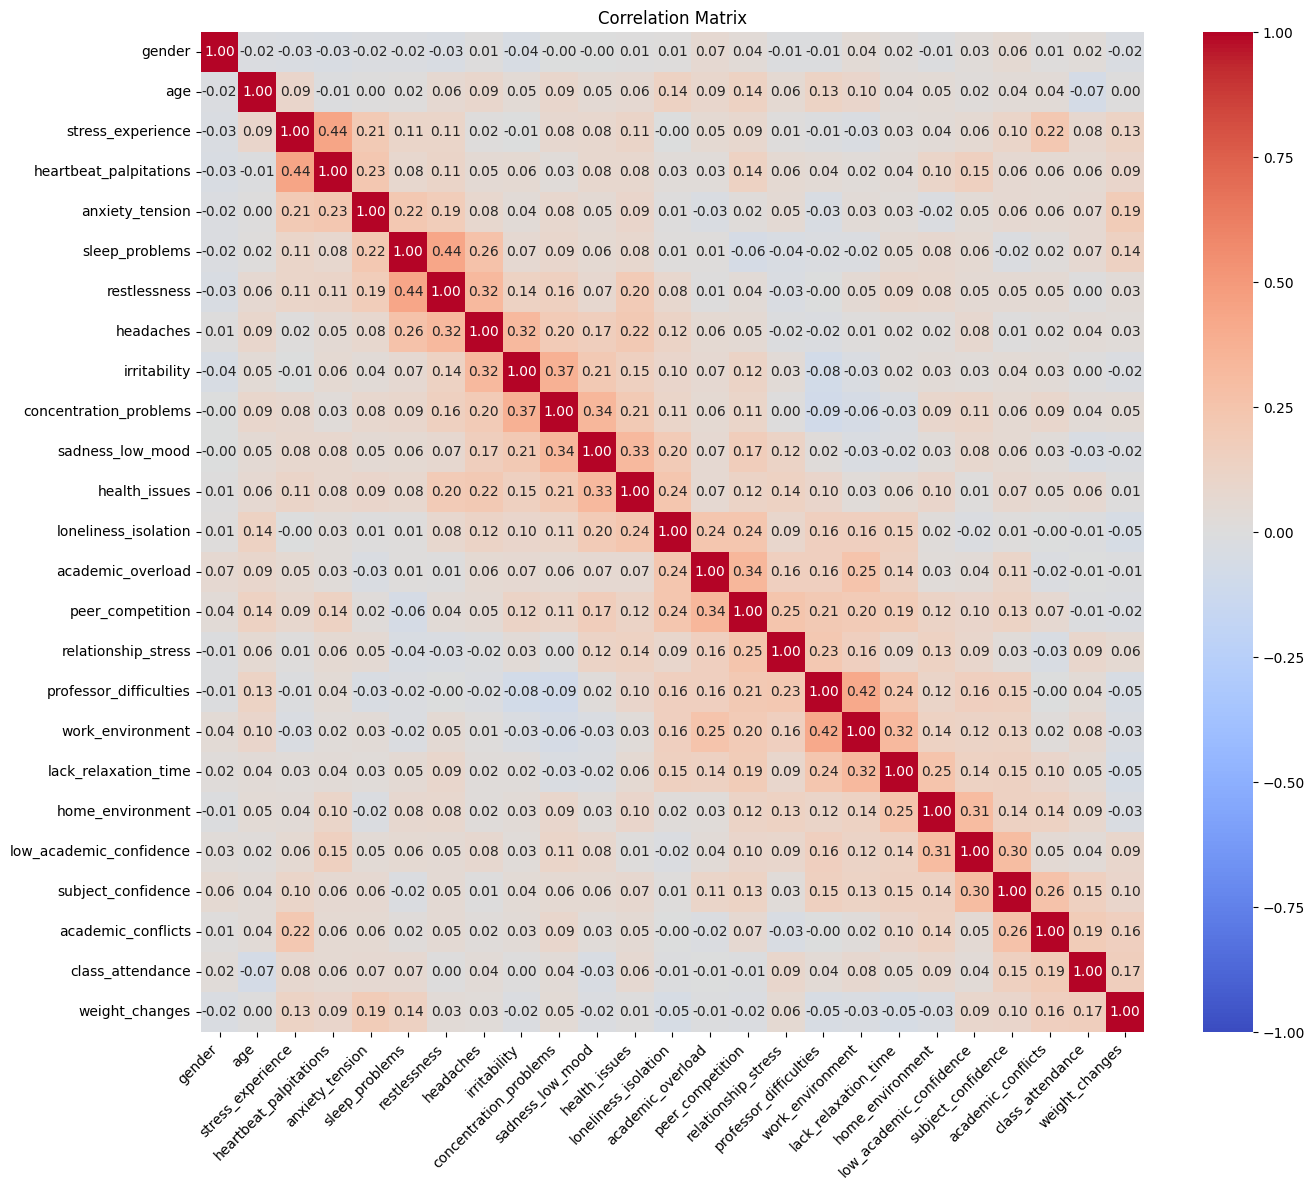

In [24]:
# Correlation Matrix
plt.figure(figsize=(14, 12))
corr_matrix = X_train.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [25]:
# Check Correlation
threshold = 0.7
high_corr = {}
max_corr = 0.0

cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        korelasi = abs(corr_matrix.iloc[i, j])

        if korelasi > max_corr:
            max_corr = korelasi

        if korelasi > threshold:
            high_corr[f"{cols[i]} — {cols[j]}"] = korelasi

if high_corr:
    print(f'Fitur dengan korelasi > {threshold}:')
    for pasangan, nilai in sorted(high_corr.items(), key=lambda x: x[1], reverse=True):
        print(f'  {pasangan}: {nilai:.3f}')
else:
    print(f'Tidak ada yang korelasi > {threshold}')
    print('Semua Fitur dipertahankan.')

print(f'\nHighest Correlation: {max_corr:.3f}')

Tidak ada yang korelasi > 0.7
Semua Fitur dipertahankan.

Highest Correlation: 0.438


# **DATA PREPROCESSING**

In [26]:
# Scaling
scaler = StandardScaler()

X_train_scaled_arr = scaler.fit_transform(X_train)
X_test_scaled_arr = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,...,relationship_stress,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes
1614,-0.737456,0.373031,-0.884260,0.202476,-0.465683,-1.407756,-0.519725,-0.503388,0.976991,-0.558893,...,0.447159,-1.215203,-1.247883,-1.195808,-0.317919,0.332258,-0.470745,-0.590176,-0.206817,-0.363742
596,-0.737456,0.373031,0.008450,-0.702244,-0.465683,0.187701,-1.296163,1.087447,0.976991,-1.321442,...,-1.163921,-1.215203,1.243951,-1.195808,-1.114873,-0.444060,0.310660,-0.590176,-1.047152,-0.363742
691,1.356013,-0.578198,-1.776971,-1.606964,-1.301540,-1.407756,-1.296163,-1.298805,0.216481,-0.558893,...,0.447159,0.468437,-0.417271,1.200669,-0.317919,-0.444060,-1.252150,-1.377254,-1.887488,-0.363742
779,-0.737456,-1.529427,-0.884260,-0.702244,-1.301540,0.985429,-1.296163,-1.298805,-1.304540,-0.558893,...,-0.358381,-0.373383,-0.417271,-0.396982,-1.114873,1.884894,-1.252150,-1.377254,1.473854,-0.363742
120,-0.737456,-0.578198,0.901161,0.202476,-0.465683,0.187701,1.033151,-0.503388,1.737501,0.203656,...,-0.358381,-0.373383,0.413340,-0.396982,0.479034,-1.220378,0.310660,-0.590176,-1.047152,-0.363742


In [27]:
# Logistic Regression
classifier = LogisticRegression(random_state=42, max_iter=1000)
classifier.fit(X_train_scaled, y_train)
y_test_pred = classifier.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.99      0.99      0.99       339
           2       0.89      0.89      0.89        18

    accuracy                           0.99       370
   macro avg       0.96      0.96      0.96       370
weighted avg       0.99      0.99      0.99       370



In [28]:
# SMOTE (Synthetic Minority Over-sampling Technique) untuk menangani Data Imbalance Class
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_up, y_train_up = smote.fit_resample(X_train_scaled, y_train)
print(y_train_up.value_counts())

stress_type
1    1357
2    1357
0    1357
Name: count, dtype: int64


In [29]:
# Logistic Regression (Setelah SMOTE)
classifier_up = LogisticRegression(random_state=42, max_iter=1000)
classifier_up.fit(X_train_up, y_train_up)
y_test_pred_up = classifier_up.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred_up))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.99      0.99       339
           2       0.82      1.00      0.90        18

    accuracy                           0.99       370
   macro avg       0.94      1.00      0.96       370
weighted avg       0.99      0.99      0.99       370



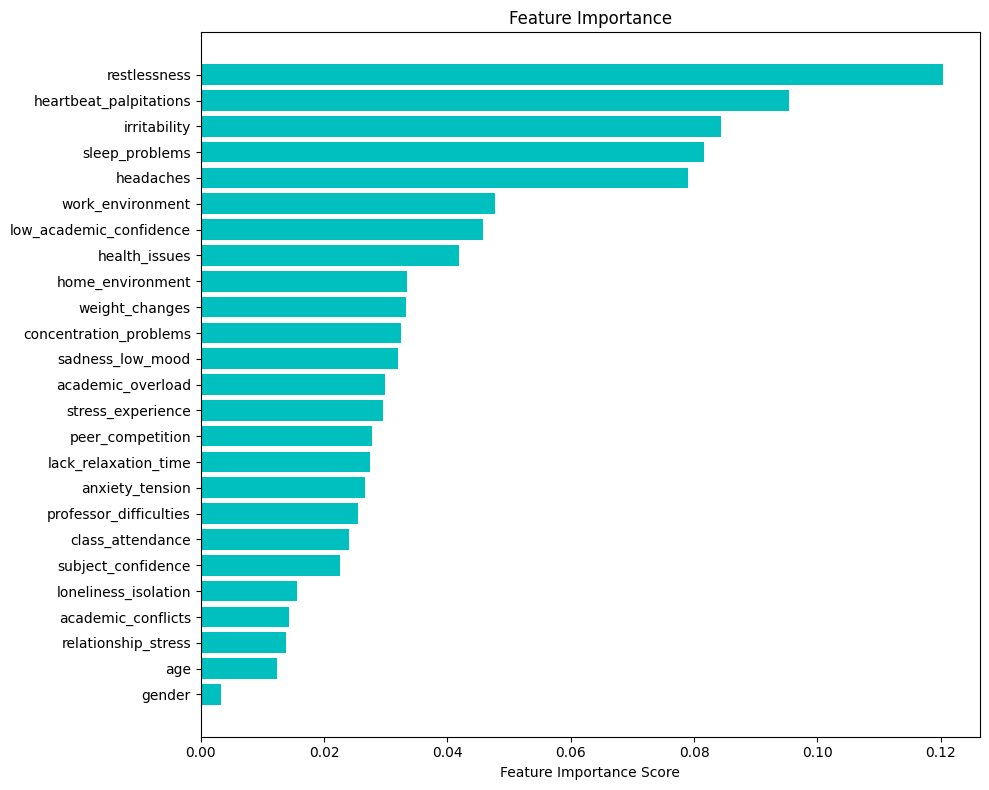

In [30]:
# Feature Importance (Random Forest)
from sklearn.ensemble import RandomForestClassifier
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train_up, y_train_up)

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance')

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='c')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

# **MODELING**

In [31]:
# Random Forest (RF)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_up, y_train_up)

y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.99      1.00      0.99       339
           2       1.00      0.72      0.84        18

    accuracy                           0.99       370
   macro avg       1.00      0.91      0.94       370
weighted avg       0.99      0.99      0.99       370



In [32]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_up, y_train_up)

y_pred_svm = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.99      0.99      0.99       339
           2       0.89      0.89      0.89        18

    accuracy                           0.99       370
   macro avg       0.96      0.96      0.96       370
weighted avg       0.99      0.99      0.99       370



In [33]:
# K-Nearest Neighbor (KNN)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_up, y_train_up)

y_pred_knn = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.62      1.00      0.76        13
           1       1.00      0.91      0.95       339
           2       0.44      1.00      0.61        18

    accuracy                           0.92       370
   macro avg       0.69      0.97      0.78       370
weighted avg       0.96      0.92      0.93       370



In [34]:
# Ensemble Machine Learning (Mahority Voting)
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('svm', SVC(kernel='linear', random_state=42)),
        ('knn', KNeighborsClassifier())
      ],
    voting='hard'
)

voting_clf.fit(X_train_up, y_train_up)

y_pred_voting = voting_clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_voting))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.99      0.99      0.99       339
           2       0.89      0.89      0.89        18

    accuracy                           0.99       370
   macro avg       0.96      0.96      0.96       370
weighted avg       0.99      0.99      0.99       370



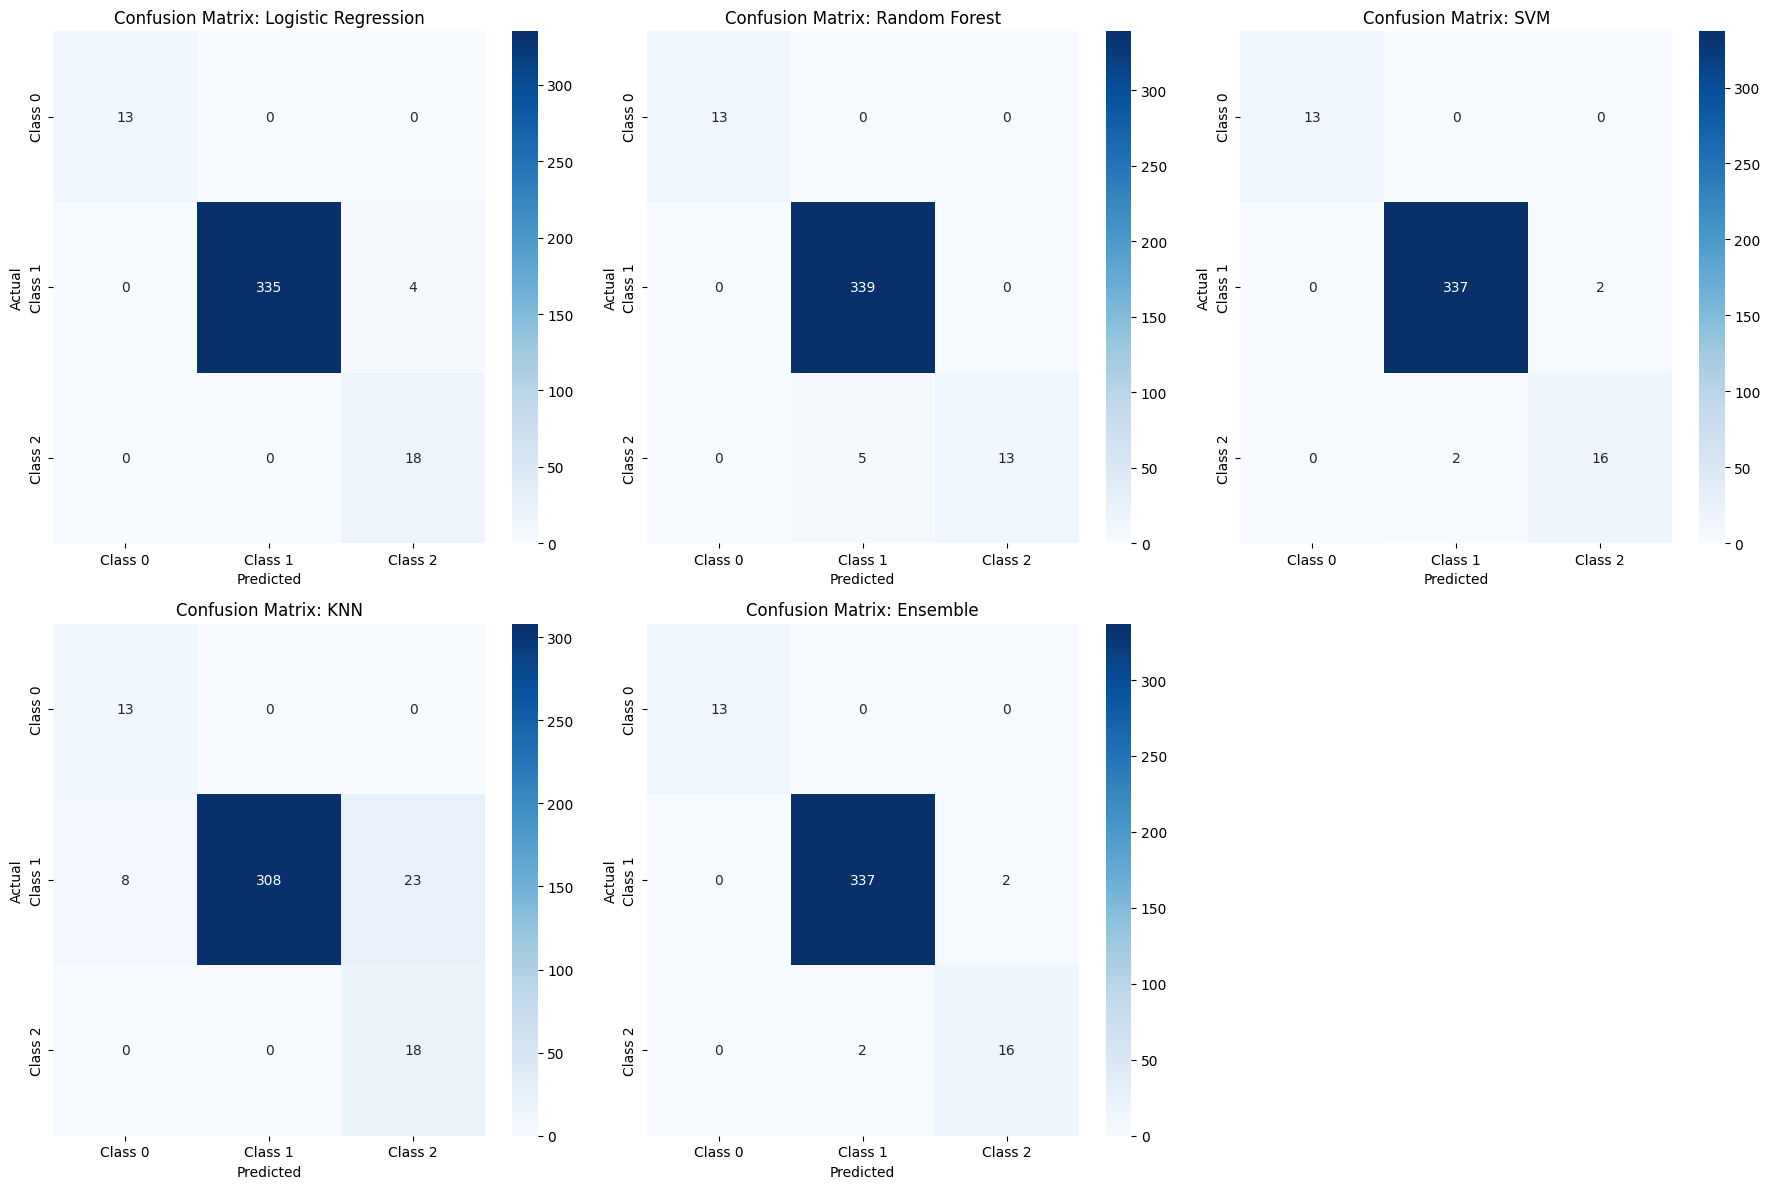

In [35]:
# Visualisasi
model_results = {
    'Logistic Regression': y_test_pred_up,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'KNN': y_pred_knn,
    'Ensemble': y_pred_voting
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, pred) in enumerate(model_results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Class 0', 'Class 1', 'Class 2'],
                yticklabels=['Class 0', 'Class 1', 'Class 2']
                )
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(len(model_results), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [36]:
# Best Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Ensemble': y_pred_voting,
    'Logistic Regression': y_test_pred_up,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'KNN': y_pred_knn
}

comparison = []
for name, prediction in models.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, prediction),
        'Precision': precision_score(y_test, prediction, average='weighted'),
        'Recall': recall_score(y_test, prediction, average='weighted'),
        'F1 Score': f1_score(y_test, prediction, average='weighted')
    })

df_compare = pd.DataFrame(comparison)
print(df_compare.sort_values(by='F1 Score', ascending=False).to_string(index=False))
best = df_compare.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print(f'Best Model: {best}')
# Dalam kasus ini, Logistic Regression, SVM, dan Ensemble seri semua

              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.989189   0.991155 0.989189  0.989698
           Ensemble  0.989189   0.989189 0.989189  0.989189
                SVM  0.989189   0.989189 0.989189  0.989189
      Random Forest  0.986486   0.986683 0.986486  0.985446
                KNN  0.916216   0.959324 0.916216  0.928869
Best Model: Logistic Regression


In [37]:
# Check Overfitting
from sklearn.metrics import accuracy_score

models_trained = {
    'Logistic Regression': (classifier_up, y_test_pred_up),
    'Random Forest': (rf, y_pred_rf),
    'SVM': (svm_model, y_pred_svm),
    'KNN': (knn, y_pred_knn),
    'Ensemble Voting': (voting_clf, y_pred_voting),
}

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>10} {'State':>12}")

for name, (mdl, y_pred) in models_trained.items():
    train_acc = accuracy_score(y_train, mdl.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_pred)
    diff = abs(train_acc - test_acc)
    status = 'Overfitting' if diff > 0.1 else 'Aman'
    print(f'{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {diff:>10.4f} {status:>12}')

Model                      Train Acc   Test Acc        Gap        State
Logistic Regression           0.9993     0.9892     0.0101         Aman
Random Forest                 1.0000     0.9865     0.0135         Aman
SVM                           1.0000     0.9892     0.0108         Aman
KNN                           0.9621     0.9162     0.0459         Aman
Ensemble Voting               1.0000     0.9892     0.0108         Aman


# **DEPLOYMENT**

In [38]:
import joblib
import os
os.makedirs('./model', exist_ok=True)

joblib.dump(voting_clf, './model/voting_model.pkl')

joblib.dump(scaler, './model/scaler.pkl')

feature_names = X_train.columns.tolist()
joblib.dump(feature_names, './model/feature_names.pkl')

['./model/feature_names.pkl']